In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
data = {
    "Study_Hours": [
        2, 3, 4, 5, 6, 7, 8, 4, 5, 6,
        7, 8, 9, 3, 4, 6, 7, 5, 8, 9
    ],

    "Sleep_Hours": [
        5, 6, 7, 6, 7, 8, 7, 5, 8, 6,
        7, 8, 7, 6, 7, 8, 6, 7, 8, 7
    ],

    "Attendance": [
        65, 70, 75, 80, 85, 90, 95, 70, 88, 82,
        91, 96, 98, 60, 72, 86, 89, 78, 94, 97
    ],

    "Score": [
        48, 52, 60, 67, 73, 82, 91, 58, 72, 70,
        81, 89, 95, 45, 55, 76, 83, 65, 88, 94
    ]
}

df = pd.DataFrame(data)

df

,Study_Hours,Sleep_Hours,Attendance,Score
0,2,5,65,48
1,3,6,70,52
2,4,7,75,60
3,5,6,80,67
4,6,7,85,73
5,7,8,90,82
6,8,7,95,91
7,4,5,70,58
8,5,8,88,72
9,6,6,82,70


In [3]:
df.describe()

,Study_Hours,Sleep_Hours,Attendance,Score
count,20.000000,20.000000,20.000000,20.000000
mean,5.800000,6.800000,83.050000,72.200000
std,2.067289,0.951453,11.362334,15.642722
min,2.000000,5.000000,60.000000,45.000000
25%,4.000000,6.000000,74.250000,59.500000
50%,6.000000,7.000000,85.500000,72.500000
75%,7.250000,7.250000,91.750000,84.250000
max,9.000000,8.000000,98.000000,95.000000


In [4]:
df.corr(numeric_only=True)

,Study_Hours,Sleep_Hours,Attendance,Score
Study_Hours,1.000000,0.567275,0.957214,0.984339
Sleep_Hours,0.567275,1.000000,0.658216,0.589852
Attendance,0.957214,0.658216,1.000000,0.986018
Score,0.984339,0.589852,0.986018,1.000000


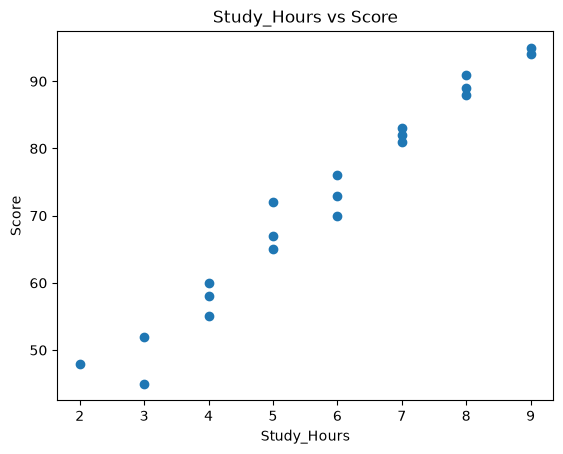

In [5]:
plt.scatter(df["Study_Hours"],df["Score"])

plt.xlabel("Study_Hours")
plt.ylabel("Score")
plt.title("Study_Hours vs Score")
plt.show()

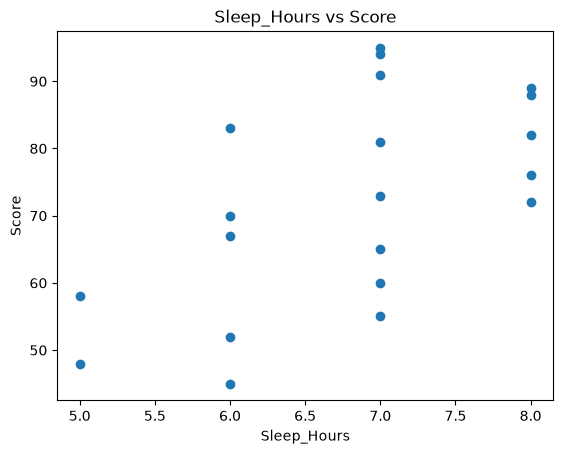

In [6]:
plt.scatter(df["Sleep_Hours"],df["Score"])

plt.xlabel("Sleep_Hours")
plt.ylabel("Score")
plt.title("Sleep_Hours vs Score")
plt.show()

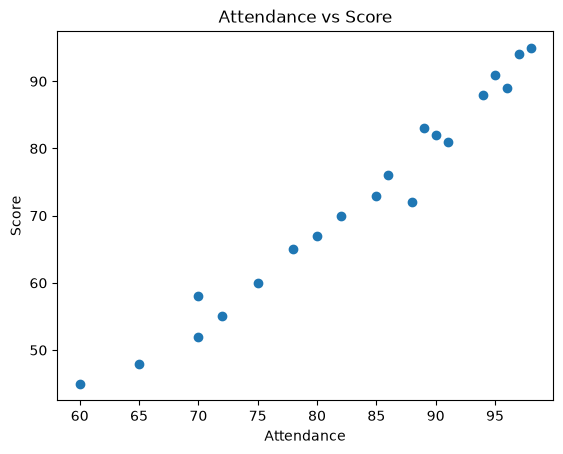

In [7]:
plt.scatter(df["Attendance"],df["Score"])

plt.xlabel("Attendance")
plt.ylabel("Score")
plt.title("Attendance vs Score")
plt.show()

In [8]:
X=df[["Study_Hours"]]
Y=df["Score"]

X_train,X_test,Y_train, Y_test=train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [9]:
model1=LinearRegression()
model1.fit(X_train, Y_train)

Y_pred1=model1.predict(X_test)

mae1=mean_absolute_error(Y_test,Y_pred1)
mse1=mean_squared_error(Y_test,Y_pred1)
rmse1=np.sqrt(mse1)
r2_1=r2_score(Y_test,Y_pred1)

print("Model1")
print("MAE1 = ",mae1)
print("MSE1 = ",mse1)
print("RMSE1 = ",rmse1)
print("R2_1 = ",r2_1)

Model1
MAE1 =  2.809090909090912
MSE1 =  11.792386363636382
RMSE1 =  3.434004421027495
R2_1 =  0.9034894210648685


In [10]:
X = df[["Study_Hours", "Sleep_Hours", "Attendance"]]
y = df["Score"]
X_train,X_test,Y_train, Y_test=train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

model2=LinearRegression()
model2.fit(X_train, Y_train)

Y_pred2=model2.predict(X_test)

mae2=mean_absolute_error(Y_test,Y_pred2)
mse2=mean_squared_error(Y_test,Y_pred2)
rmse2=np.sqrt(mse2)
r2_2=r2_score(Y_test,Y_pred2)

print("Model2")
print("MAE2 = ",mae2)
print("MSE2 = ",mse2)
print("RMSE2 = ",rmse2)
print("R2_2 = ",r2_2)

Model2
MAE2 =  1.198980751742953
MSE2 =  2.651004547013284
RMSE2 =  1.6281905745376626
R2_2 =  0.9783037991037276


In [11]:
comparison=pd.DataFrame({
    "Model" : ["Study_Hours only","Study+Sleep+Attendance"],
    "MAE"  : [mae1,mae2],
    "MSE" :[mse1,mse2],
    "R2" :[r2_1,r2_2]
})

comparison

,Model,MAE,MSE,R2
0,Study_Hours only,2.809091,11.792386,0.903489
1,Study+Sleep+Attendance,1.198981,2.651005,0.978304


In [13]:
print("Intercept :",model2.intercept_)
print("Coefficients : ")
for feature, coefficient in zip(X.columns, model2.coef_):
    print(feature, ":", coefficient )

Intercept : -8.165743407093132
Coefficients : 
Study_Hours : 3.6996210973022117
Sleep_Hours : -0.8302137011215508
Attendance : 0.7746059411943021


In [15]:
df["Study_Sleep_Ratio"]=(df["Study_Hours"]
                         /df["Sleep_Hours"])
df["Attendance_Rate"]=df["Attendance"]/100
df

,Study_Hours,Sleep_Hours,Attendance,Score,Study_Sleep_Ratio,Attendance_Rate
0,2,5,65,48,0.400000,0.65
1,3,6,70,52,0.500000,0.70
2,4,7,75,60,0.571429,0.75
3,5,6,80,67,0.833333,0.80
4,6,7,85,73,0.857143,0.85
5,7,8,90,82,0.875000,0.90
6,8,7,95,91,1.142857,0.95
7,4,5,70,58,0.800000,0.70
8,5,8,88,72,0.625000,0.88
9,6,6,82,70,1.000000,0.82


In [19]:
#model 3
X=df[["Study_Hours","Sleep_Hours","Attendance","Study_Sleep_Ratio"]]
Y=df["Score"]

#Train test split
X_train,X_test,Y_train, Y_test=train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

#Model training
model3=LinearRegression()
model3.fit(X_train,Y_train)

#model testing
Y_pred3=model3.predict(X_test)

#Model evaluation
error3=Y_test.values-Y_pred3
print("Error3 : ",error3)
mae3=mean_absolute_error(Y_test,Y_pred3)
print("MAE3 : ",mae3)
mse3=mean_squared_error(Y_test,Y_pred3)
print("MSE3 : ",mse3)
rmse3=np.sqrt(mse3)
print("RMSE3 : ",rmse3)
r2_3=r2_score(Y_test,Y_pred3)
print("R2 : ",r2_3)

#comparison
comparison=pd.DataFrame({
    "Model":["Study Hours only", "Study+Sleep+Attendance","Model2+Engineered features"],
    "MAE" :[mae1, mae2,mae3],
    "MSE" :[mse1,mse2,mse3],
    "RMSE" : [rmse1,rmse2,rmse3],
    "R2" : [r2_1,r2_2,r2_3]
})

comparison

Error3 :  [ 0.10961988  0.23955851  2.36151735 -1.15233921]
MAE3 :  0.9657587333835309
MSE3 :  1.7435136535515192
RMSE3 :  1.320421771083588
R2 :  0.985730834548939


,Model,MAE,MSE,RMSE,R2
0,Study Hours only,2.809091,11.792386,3.434004,0.903489
1,Study+Sleep+Attendance,1.198981,2.651005,1.628191,0.978304
2,Model2+Engineered features,0.965759,1.743514,1.320422,0.985731
